# AA Sports MLB — auditoría de aprendizaje e ingesta

**Snapshot:** 21 de julio de 2026.

**Pregunta:** ¿qué debe corregirse y cómo capturar cada 20 minutos sin romper el free tier ni introducir fuga temporal?

> TL;DR: el cuello de botella es integridad temporal. Las filas nativas se sobrescriben intradía; primero se congela el snapshot oficial y luego se prueban modelos más complejos.

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
assert (ROOT / 'data/history/games').exists(), ROOT
SNAP = json.loads((ROOT / 'docs/analysis/mlb_intelligence_audit_snapshot.json').read_text())
LEARNING = json.loads((ROOT / 'data/history/learning.json').read_text())
print('repo:', ROOT)
print('audit generated_at:', SNAP['generated_at'])
print('repo sha:', SNAP['repo_sha'][:12])

repo: /Users/adrianclara/aa-sports-cf
audit generated_at: 2026-07-21T17:49:45Z
repo sha: 6086684864ab


## 1. Perfil reproducible del histórico

La celda siguiente vuelve a leer todos los `games_v1`. Los duplicados se miden por `game_pk`; un juego aplazado que reaparece conserva el mismo ID, pero un outcome no debe contarse dos veces.

In [2]:
game_files = sorted((ROOT / 'data/history/games').glob('2026-*.json'))
rows = []
for fp in game_files:
    doc = json.loads(fp.read_text())
    rows.extend({**row, '_file': fp.name} for row in doc.get('games', []))

ids = [row.get('game_pk') for row in rows]
graded = [row for row in rows if row.get('graded') and row.get('home_win') in (0, 1)]
profile = {
    'days': len(game_files),
    'rows': len(rows),
    'graded': len(graded),
    'unique_game_pk': len(set(ids)),
    'duplicate_rows': len(ids) - len(set(ids)),
}
assert profile['rows'] == SNAP['inventory']['rows']
assert profile['graded'] == SNAP['inventory']['graded']
display(pd.DataFrame([profile]))

,days,rows,graded,unique_game_pk,duplicate_rows
0,116,1544,1506,1528,16


In [3]:
from collections import defaultdict
appearances = defaultdict(list)
for row in rows:
    appearances[row.get('game_pk')].append(row)
duplicate_examples = []
for game_pk, group in appearances.items():
    if len(group) > 1:
        duplicate_examples.append({
            'game_pk': game_pk,
            'appearances': len(group),
            'dates': ', '.join(str(x.get('date')) for x in group),
            'graded_rows': sum(bool(x.get('graded')) for x in group),
            'statuses': ', '.join(str(x.get('status')) for x in group),
        })
display(pd.DataFrame(duplicate_examples).sort_values(['graded_rows', 'game_pk'], ascending=[False, True]).head(16))

,game_pk,appearances,dates,graded_rows,statuses
11,824912,2,"2026-06-16, 2026-06-17",2,"Final, Final"
6,823062,2,"2026-05-05, 2026-07-07",1,"Postponed, Final"
13,823357,2,"2026-07-10, 2026-07-11",1,"Postponed, Final"
4,823471,2,"2026-04-29, 2026-04-30",1,"Postponed, Final"
15,823523,2,"2026-07-18, 2026-07-19",1,"Postponed, Final"
12,823613,2,"2026-06-22, 2026-06-24",1,"Postponed, Final"
3,823637,2,"2026-04-25, 2026-04-26",1,"Postponed, Final"
1,824134,2,"2026-04-03, 2026-04-04",1,"Postponed, Final"
7,824362,2,"2026-05-05, 2026-05-07",1,"Postponed, Final"
14,824414,2,"2026-07-17, 2026-07-18",1,"Postponed, Final"


## 2. Integridad del récord público

Los horarios de first pitch no están almacenados para todo el histórico. La auditoría timestamp-a-timestamp unió cada `game_pk` con `gameDate` de StatsAPI. El snapshot conserva ese resultado verificable: 13 de 49 picks resueltos fueron creados después del inicio; el récord estrictamente pregame queda 18–18.

In [4]:
rec = SNAP['public_record_integrity']
record_df = pd.DataFrame([
    {'cohort': 'Mostrado', 'n': rec['plays_resolved'], **rec['reported']},
    {'cohort': 'Post-start / retrospectivo', 'n': rec['post_start']['n'], 'wins': rec['post_start']['wins'], 'losses': rec['post_start']['losses'], 'rate': rec['post_start']['rate']},
    {'cohort': 'Live pregame estricto', **rec['strict_prestart']},
])
display(record_df[['cohort', 'n', 'wins', 'losses', 'rate']].style.format({'rate': '{:.1%}'}))

,cohort,n,wins,losses,rate
0,Mostrado,49,26,23,53.1%
1,Post-start / retrospectivo,13,8,5,61.5%
2,Live pregame estricto,36,18,18,50.0%


## 3. Métricas actuales: útiles para diagnóstico, no para promoción

El learner reduce log-loss/Brier frente al clásico, pero no mejora acierto y el mercado sigue mejor. La advertencia es esencial: las filas nativas no son snapshots inmutables, por lo que esta comparación debe repetirse con datos pregame limpios.

,model,accuracy,logloss,brier
0,Clásico,54.22%,0.7209,0.2621
1,Aprendido,53.72%,0.6953,0.2510
2,Combinado,53.86%,0.6942,0.2504
3,Mercado,56.43%,0.6845,0.2457


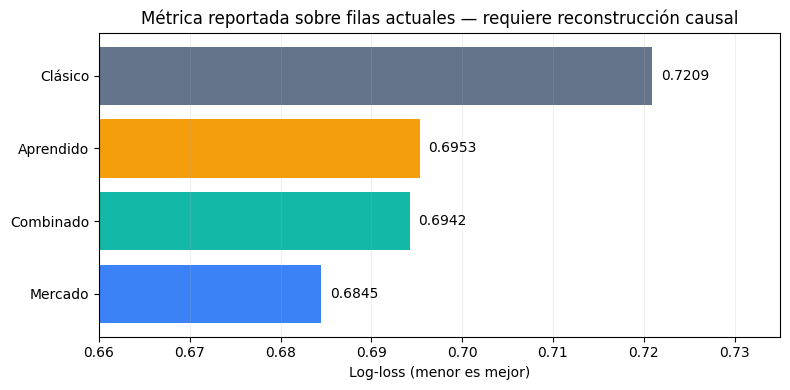

In [5]:
m = SNAP['reported_model_metrics']
metrics = pd.DataFrame([
    {'model': 'Clásico', **m['classic']},
    {'model': 'Aprendido', **m['learned']},
    {'model': 'Combinado', **{k: v for k, v in m['combined'].items() if k != 'ece'}},
    {'model': 'Mercado', **{k: v for k, v in m['market'].items() if k != 'n'}},
])
display(metrics.style.format({'accuracy': '{:.2%}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#64748b', '#f59e0b', '#14b8a6', '#3b82f6']
ax.barh(metrics['model'], metrics['logloss'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Log-loss (menor es mejor)')
ax.set_title('Métrica reportada sobre filas actuales — requiere reconstrucción causal')
ax.set_xlim(0.66, 0.735)
for i, value in enumerate(metrics['logloss']):
    ax.text(value + 0.001, i, f'{value:.4f}', va='center')
ax.grid(axis='x', alpha=.2)
plt.tight_layout()
plt.show()

## 4. Robustez estadística

El bootstrap original usa una multiplicación LCG que excede el rango entero exacto de JavaScript. Una repetición con xorshift32 y otra por bloques de fecha vuelven a centrar las medias. La mejora de log-loss continúa en el dataset actual, mientras el acierto cruza cero; aun así, ninguna de las dos corrige la mutabilidad temporal de `X`.

In [6]:
boot = SNAP['bootstrap_audit']
corr = boot['corrected_iid_5000']['delta_combined_minus_classic']
block = boot['corrected_date_block_10000']
display(pd.DataFrame([
    {'method': 'IID corregido', 'metric': 'accuracy', 'delta': corr['accuracy_mean'], 'ci_lo': corr['accuracy_ci95'][0], 'ci_hi': corr['accuracy_ci95'][1]},
    {'method': 'IID corregido', 'metric': 'logloss', 'delta': corr['logloss_mean'], 'ci_lo': corr['logloss_ci95'][0], 'ci_hi': corr['logloss_ci95'][1]},
    {'method': 'IID corregido', 'metric': 'brier', 'delta': corr['brier_mean'], 'ci_lo': corr['brier_ci95'][0], 'ci_hi': corr['brier_ci95'][1]},
    {'method': 'Bloques por fecha', 'metric': 'logloss', 'delta': block['delta_logloss_mean'], 'ci_lo': block['delta_logloss_ci95'][0], 'ci_hi': block['delta_logloss_ci95'][1]},
]).style.format({'delta': '{:+.4f}', 'ci_lo': '{:+.4f}', 'ci_hi': '{:+.4f}'}))

,method,metric,delta,ci_lo,ci_hi
0,IID corregido,accuracy,-0.0035,-0.0279,+0.0207
1,IID corregido,logloss,-0.0269,-0.0403,-0.0139
2,IID corregido,brier,-0.0117,-0.0180,-0.0057
3,Bloques por fecha,logloss,-0.0270,-0.0412,-0.0129


## 5. Frecuencia real y presupuesto $0

Los runs terminan correctamente, pero GitHub no constituye un reloj horario. Cloudflare Cron captura; GitHub Actions computa de forma privada cuando puede consumir los slots nuevos.

In [7]:
wf = SNAP['workflow_reliability']
budget = SNAP['free_tier_design']
display(pd.DataFrame([{
    'scheduled_runs': wf['scheduled_runs'],
    'success': wf['success'],
    'gap_p50_min': wf['gap_minutes']['p50'],
    'gap_p90_min': wf['gap_minutes']['p90'],
    'gap_max_min': wf['gap_minutes']['max'],
    'gaps_gt_90': wf['gap_minutes']['gt_90'],
}]))
display(pd.DataFrame([{
    'capture_ticks_day': budget['capture_invocations_per_day'],
    'upstream_fetches_day': budget['upstream_fetches_per_day'],
    'd1_writes_day_low': budget['d1_row_writes_per_day_estimate'][0],
    'd1_writes_day_high': budget['d1_row_writes_per_day_estimate'][1],
    'full_workflow_kv_writes_day': budget['full_workflow_every_20m_kv_writes_per_day_estimate'],
    'kv_free_limit': budget['kv_free_writes_per_day'],
}]))

,scheduled_runs,success,gap_p50_min,gap_p90_min,gap_max_min,gaps_gt_90
0,100,100,127.83,200.1,232.2,73


,capture_ticks_day,upstream_fetches_day,d1_writes_day_low,d1_writes_day_high,full_workflow_kv_writes_day,kv_free_limit
0,72,144,72,144,1029,1000


## 6. Plan de decisión

1. **P0:** snapshot oficial inmutable, ledger estrictamente pregame, ORO en sombra, totales/F5 con mercado real, dedupe y RNG determinista.
2. **Ingesta:** cron Worker cada 20 minutos a D1 append-only; cero lógica privada y cero commits intradía.
3. **Baseline limpio:** replay idéntico a producción, nested walk-forward, bootstrap por fecha, versionado y rollback.
4. **Challengers:** residual al mercado, ablations, bullpen/abridor y horizonte T−90m.
5. **Aprendizaje gobernado:** outcomes Final, refit diario, promoción semanal y abstención.

La especificación completa está en `docs/MLB_INTELLIGENCE_PLAN.md`.

In [8]:
display(pd.DataFrame(SNAP['roadmap']))

,phase,scope,exit_gate
0,0 - Integrity,"Immutable decision snapshot, prestart ledger, ...","Zero post-start training rows, zero feature mu..."
1,1 - 20-minute capture,Cloudflare Cron plus idempotent D1 slots; spli...,Capture age <=30 minutes during active slate a...
2,2 - Clean champion,"End-to-end production replay, nested walk-forw...",Champion metrics reproduced from immutable sam...
3,3 - Shadow challengers,"Market-residual model, ablations, starter/bull...",Independent forward gates pass; otherwise rema...
4,4 - Governed continuous learning,"Drift, daily refit, weekly promotion and price...",Stable forward improvement with operational an...


## Takeaways

- Más frecuencia sirve para **capturar estados**, no para reentrenar con juegos sin resultado.
- El learner parece mejorar calibración, pero la tasa de acierto no mejora y la evidencia debe rehacerse con `X` inmutable.
- El gate ORO actual deja de pasar al excluir filas nativas contaminadas.
- Over/F5 no se publican hasta tener línea, precio, timestamp y muestra forward real.
- El primer boost defendible es saber exactamente qué sabía el algoritmo y cuándo.